In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

import torch
from diffusers import UNet2DModel
from diffusers.models.attention_processor import AttnProcessor2_0


In [ ]:
# class SinusoidalEmbedding(nn.Module):
#     def __init__(self, size: int, scale: float = 1.0):
#         super().__init__()
#         self.size = size
#         self.scale = scale

#     def forward(self, x: torch.Tensor):
#         x = x * self.scale
#         half_size = self.size // 2
#         emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
#         emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
#         emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
#         emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
#         return emb


# class ConvBlock(nn.Module):
#     def __init__(self, in_ch, out_ch, time_emb_dim):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
#         self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
#         self.norm1 = nn.GroupNorm(8, out_ch)
#         self.norm2 = nn.GroupNorm(8, out_ch)
#         self.time_mlp = nn.Linear(time_emb_dim, out_ch)

#     def forward(self, x, t_emb):
#         h = self.norm1(F.gelu(self.conv1(x)))
#         h = h + self.time_mlp(t_emb)[:, :, None, None]
#         h = self.norm2(F.gelu(self.conv2(h)))
#         return h


# class DownBlock(nn.Module):
#     def __init__(self, in_ch, out_ch, time_emb_dim):
#         super().__init__()
#         self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
#         self.pool = nn.MaxPool2d(2)

#     def forward(self, x, t_emb):
#         skip = self.conv(x, t_emb)
#         return self.pool(skip), skip


# class UpBlock(nn.Module):
#     def __init__(self, in_ch, out_ch, time_emb_dim):
#         super().__init__()
#         self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
#         self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

#     def forward(self, x, skip, t_emb):
#         x = self.up(x)
#         x = torch.cat([x, skip], dim=1)
#         return self.conv(x, t_emb)


# class SimpleUNet(nn.Module):
#     def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
#         super().__init__()
        
#         self.time_proj = nn.Sequential(
#             SinusoidalEmbedding(time_emb_dim),
#             nn.Linear(time_emb_dim, time_emb_dim),
#             nn.GELU()
#         )
        
#         self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
#         self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7
        
#         self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        
#         self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
#         self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28
        
#         self.out = nn.Conv2d(base_ch, in_channels, 1)

#     def forward(self, x, t):
#         '''
#         :x input [bs, C, H, W] - image
#         :t 1d torch.LongTensor of timesteps
#         '''
#         t_emb = self.time_proj(t)
        
#         x, skip1 = self.down1(x, t_emb)
#         x, skip2 = self.down2(x, t_emb)
        
#         x = self.bottleneck(x, t_emb)
        
#         x = self.up1(x, skip2, t_emb)
#         x = self.up2(x, skip1, t_emb)
        
#         return self.out(x)

In [92]:
clip = transforms.Lambda(lambda x: x.clip(-1.0, 1.0))
scale = transforms.Lambda(lambda x: x * 2 - 1)
unscale = transforms.Lambda(lambda x: (x + 1) / 2)

train_dataset = torchvision.datasets.CIFAR10(
        root='.', 
        train=True, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            scale,
            clip,
        ])
    )

test_dataset = torchvision.datasets.CIFAR10(
        root='.', 
        train=False, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            scale,
            clip,
        ])
    )

In [93]:
def fft_forward_process(image, t):
    # image: [C, H, W] or [B, C, H, W] — fft2 operates on last 2 dims
    fft = torch.fft.fft2(image)
    shifted_fft = torch.fft.fftshift(fft, dim=(-2, -1))

    H, W = image.shape[-2:]
    h_center, w_center = H // 2, W // 2

    h_low  = max(0, h_center - t)
    h_high = min(H, h_center + t)
    w_low  = max(0, w_center - t)
    w_high = min(W, w_center + t)

    # mask shape matches [C, H, W] or [B, C, H, W] automatically
    mask = torch.zeros_like(shifted_fft, dtype=torch.bool)
    mask[..., h_low:h_high, w_low:w_high] = True
    shifted_fft = shifted_fft * mask

    unshifted_fft = torch.fft.ifftshift(shifted_fft, dim=(-2, -1))
    restored = torch.fft.ifft2(unshifted_fft).real
    return restored

In [94]:
losses = []

log_every_n = 10
num_train_steps = 200
num_epoches = 50
step = 0 
HIGH = 32

In [104]:
DEVICE = "cuda:0"

# model = SimpleUNet(in_channels=3, base_ch=128, time_emb_dim=128).to(DEVICE)
model = UNet2DModel(
    # num_class_embeds=10,
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
    attention_head_dim=4,
    norm_num_groups=32,
    mid_block_type="UNetMidBlock2D",
)

# Move to device first
model = model.to(DEVICE)

# 🔥 Manual method to enable FlashAttention-2 (works across diffusers versions)
def set_attn_processors(model, processor):
    """Recursively set attention processors for all attention modules in the model."""
    for name, module in model.named_modules():
        if hasattr(module, "set_processor"):
            module.set_processor(processor)
        # For older diffusers versions where attention modules have 'processor' attribute directly
        elif hasattr(module, "processor") and "Attention" in module.__class__.__name__:
            module.processor = processor

# Check if we can use AttnProcessor2_0 (PyTorch 2.0+ with efficient SDPA)
if hasattr(torch.nn.functional, "scaled_dot_product_attention"):
    processor = AttnProcessor2_0()
    print("✅ Using AttnProcessor2_0 (PyTorch 2.0 scaled_dot_product_attention)")
else:
    from diffusers.models.attention_processor import AttnProcessor
    processor = AttnProcessor()
    print("⚠️ PyTorch 2.0 not available. Using default attention processor.")

# Apply the processor to all attention modules
set_attn_processors(model, processor)

# Also ensure we're using bfloat16 if available and beneficial
if torch.cuda.is_bf16_supported():
    use_bf16 = True
    print("✅ bfloat16 is supported on this device")
else:
    use_bf16 = False
    print("⚠️ bfloat16 not supported, using float32")


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print(f"Number of parameters: {sum([p.numel() for p in model.parameters()]) / 1e6:.2f}M")


✅ Using AttnProcessor2_0 (PyTorch 2.0 scaled_dot_product_attention)
✅ bfloat16 is supported on this device
Number of parameters: 25.84M


In [102]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128, 
    shuffle=True
)

In [108]:
model.train()

for epoch in range(num_epoches):
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epoches}')
    for images, labels in pbar:
        batch_src = []
        batch_dst = []

        # rec_step = torch.randint(size=(images.shape[0],), low=1, high=HIGH - 1)

        # Bias sampling towards earlier steps using exponential distribution
        weights = torch.exp(-0.5 * torch.arange(1, HIGH - 1, dtype=torch.float))
        weights = weights / weights.sum()
        rec_step = torch.multinomial(weights, images.shape[0], replacement=True) + 1
                
        for i in range(images.shape[0]):
            our_sample = images[i]  # [C, H, W]
            
            src = fft_forward_process(our_sample, rec_step[i])
            
            dst = fft_forward_process(our_sample, rec_step[i] + 1)
    
            batch_src.append(src.unsqueeze(dim=0))
            batch_dst.append(dst.unsqueeze(dim=0))
            
        src = torch.cat(batch_src, dim=0).to(DEVICE)
        dst = torch.cat(batch_dst, dim=0).to(DEVICE)
        target = dst.to(DEVICE)
        rec_step = rec_step.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, rec_step)
        output = output.sample
        
        loss = F.l1_loss(output, target)
    
        if step % log_every_n == 0:
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
        losses.append(loss.item())
    
        step += 1

Epoch 1/50:  32%|███▏      | 125/391 [00:22<00:47,  5.55it/s, loss=0.082883]


KeyboardInterrupt: 

In [72]:
torch.save(model.state_dict(), 'fft_cifar_model_128_128_50ep.pth')

### Fitting prior:

In [73]:
src_priors = []

n_batches_to_fit_prior = 100
for batch_num, (images, labels) in tqdm(enumerate(test_loader), desc='Collecting src(t=1) for prior'):
    for i in range(images.shape[0]):
        src_priors.append(fft_forward_process(images[i], 1))
    if batch_num > n_batches_to_fit_prior:
        break

def fit_gaussian_rgb(samples_list, eps=1e-5):
    samples = torch.stack([s.flatten() for s in samples_list])  # [N, 3072]
    mean = samples.mean(dim=0)                                 # [3072]

    centered = samples - mean
    n = samples.shape[0]
    cov = centered.T @ centered / (n - 1)                      # [3072, 3072]

    cov = cov + eps * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
    return mean.view(3, 32, 32), cov

def sample_from_gaussian_rgb(mean, cov, n_samples=1):
    mean_flat = mean.flatten()
    dist = torch.distributions.MultivariateNormal(
        mean_flat,
        covariance_matrix=cov
    )
    samples = dist.sample((n_samples,))                        # [n_samples, 3072]
    return samples.view(n_samples, 3, 32, 32)

In [74]:
mean_img, cov_matrix = fit_gaussian_rgb(src_priors)

print(mean_img.shape)   # [3, 32, 32]
print(cov_matrix.shape) # [3072, 3072]

samples = sample_from_gaussian_rgb(mean_img, cov_matrix, n_samples=4)
print(samples.shape)    # [4, 3, 32, 32]

torch.Size([3, 32, 32])
torch.Size([3072, 3072])
torch.Size([4, 3, 32, 32])


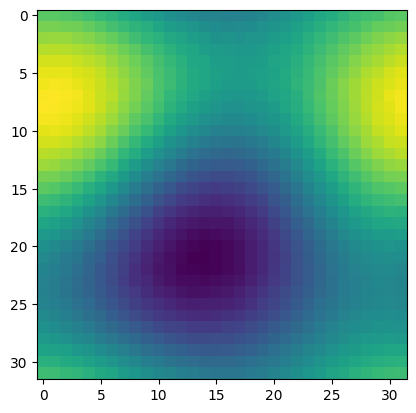

In [75]:
plt.imshow(samples[2][0])

### Generation:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06769472..1.1043459].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05743909..1.0681837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05146855..1.1202964].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014711022..1.1068817].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03055507..1.1783023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020484626..1.0703893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-

<Figure size 640x480 with 0 Axes>

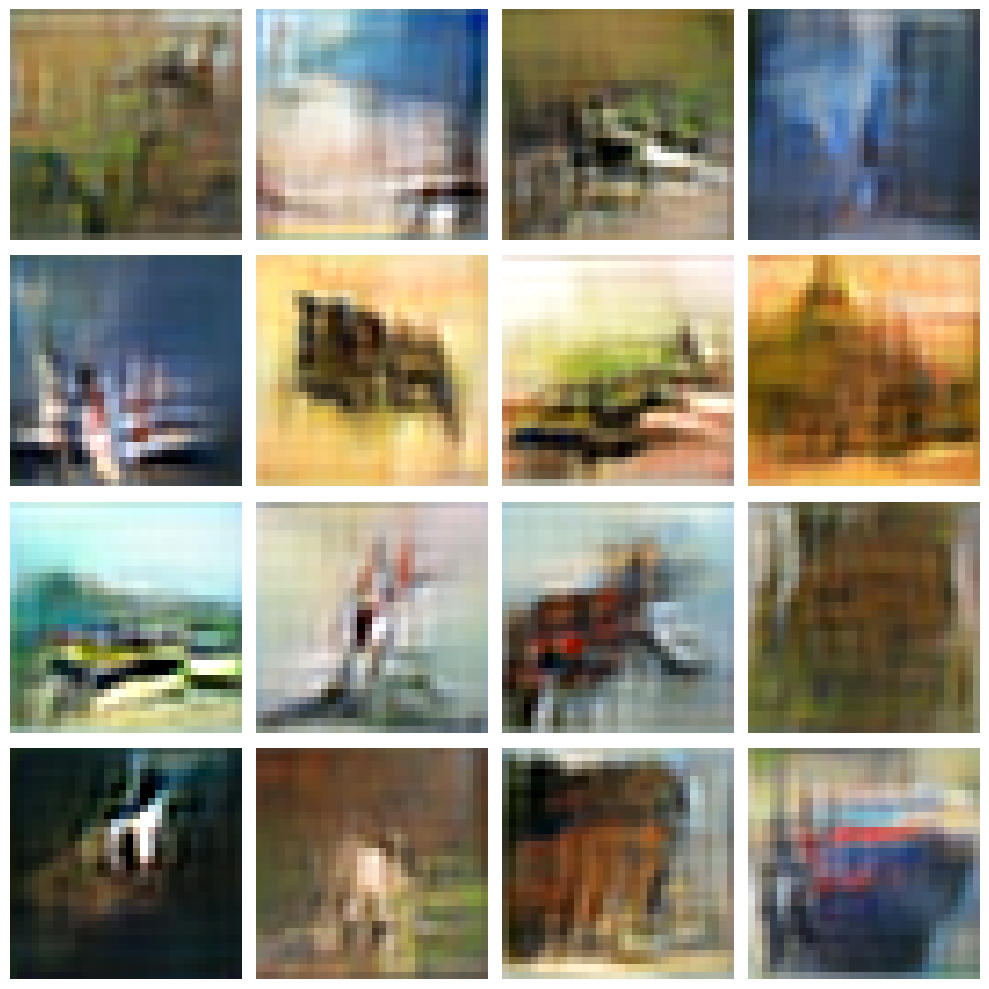

In [90]:
imgs = []
fig = plt.figure()

# x_t = src[None, None].to(DEVICE)
sampled_gaussian_prior = sample_from_gaussian_rgb(mean_img, cov_matrix, n_samples=16)
x_t = sampled_gaussian_prior.to(DEVICE)

model.eval()

for t in range(1, 10):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )

# Plot grid of batch images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(min(16, x_t.shape[0])):
    axes[i].imshow(
        # x_t[i][0].cpu()
        unscale(x_t[i].cpu().permute(1, 2, 0))
    )
    axes[i].axis('off')

# Hide any unused subplots
for i in range(x_t.shape[0], 16):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [52]:
img_gen = x_t[0].cpu()